# Adaptation de RISE aux séquences

Dans cette partie du projet, nous cherchons à adapter la logique de la méthode RISE à des données textuelles, plus précisément des séquences de protéines.

Au lieu de travailler sur les pixels d'une image, nous générons des masques pour cacher aléatoirement certains tokens de la séquence d'entrée. L'expérience permet ainsi d'identifier les acides aminés exacts qui ont le plus pesé dans la prédiction finale de notre modèle NLP.


In [66]:
import os
from pathlib import Path

import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

from scripts.models.rise_seq import compute_rise_saliency_seq
from scripts.tools_for_data.seq_data import read_fasta

## Model and sequence 

In [ ]:
MODEL_ID = "Tarive/esm2_t12_35M_UR50D-finetuned-pfam-1k"

sequence = "MKWVTFISLLFLFSSAYSRGVFRRDAHKSEVAHRFKDLGE"

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## Dataset (Hugging Face Datasets)

In [ ]:
from datasets import load_dataset

ds = load_dataset("DanielHesslow/SwissProt-Pfam", split="train")
sample = ds[0]
sequence = sample["seq"]
labels = sample["labels"]
target_class = None
sequence[:60], labels

('MSKIIEYDETARRAIEAGVNTLADAVRVTLGPRGRHVVLAKAFGGPAVTNDGVTVAREID', [4358])

## load tokenizer and model

In [69]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.mask_token_id is None:
    raise ValueError("Tokenizer has no mask token; cannot run RISE masking.")

model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID).to(device)
model.eval()

Loading weights: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 213/213 [00:00<00:00, 3618.37it/s]


EsmForSequenceClassification(
  (esm): EsmModel(
    (embeddings): EsmEmbeddings(
      (word_embeddings): Embedding(33, 480, padding_idx=1)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): EsmEncoder(
      (layer): ModuleList(
        (0-11): 12 x EsmLayer(
          (attention): EsmAttention(
            (self): EsmSelfAttention(
              (query): Linear(in_features=480, out_features=480, bias=True)
              (key): Linear(in_features=480, out_features=480, bias=True)
              (value): Linear(in_features=480, out_features=480, bias=True)
              (rotary_embeddings): RotaryEmbedding()
            )
            (output): EsmSelfOutput(
              (dense): Linear(in_features=480, out_features=480, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (LayerNorm): LayerNorm((480,), eps=1e-05, elementwise_affine=True)
          )
          (intermediate): EsmIntermediate(
            (dense): Linear(in_featur

## Mapping id -> label

In [70]:
from scripts.tools_for_data.label_mapping import load_id2label

id2label = load_id2label(MODEL_ID)
def label_name(idx):
    return id2label.get(int(idx), f"LABEL_{idx}")

len(id2label), list(id2label.items())[:5]

(1000,
 [(0, 'LABEL_0'),
  (1, 'LABEL_1'),
  (2, 'LABEL_2'),
  (3, 'LABEL_3'),
  (4, 'LABEL_4')])

## Tokenization + prediction

In [71]:
inputs = tokenizer(sequence, return_tensors="pt", truncation=True, max_length=1024)
input_ids = inputs["input_ids"]
attention_mask = inputs.get("attention_mask", torch.ones_like(input_ids))

with torch.no_grad():
    logits = model(input_ids=input_ids.to(device), attention_mask=attention_mask.to(device)).logits
pred_class = int(torch.sigmoid(logits)[0].argmax().item())
pred_class, label_name(pred_class)

(54, 'LABEL_54')

## RISE-SEQ

In [97]:
target_class = pred_class if target_class is None else target_class

saliency = compute_rise_saliency_seq(
    model=model,
    input_ids=input_ids,
    attention_mask=attention_mask,
    pred_class=target_class,
    mask_token_id=tokenizer.mask_token_id,
    num_masks=3000,
    p1=0.3,
    s=32,
    device=device,
    batch_size=32,
    special_token_ids=tokenizer.all_special_ids,
    multi_label=False,
)
saliency.shape

RISE-SEQ: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 94/94 [20:13<00:00, 12.91s/it]


(540,)

## Visualisation

In [87]:
len(values[1:-1])

538

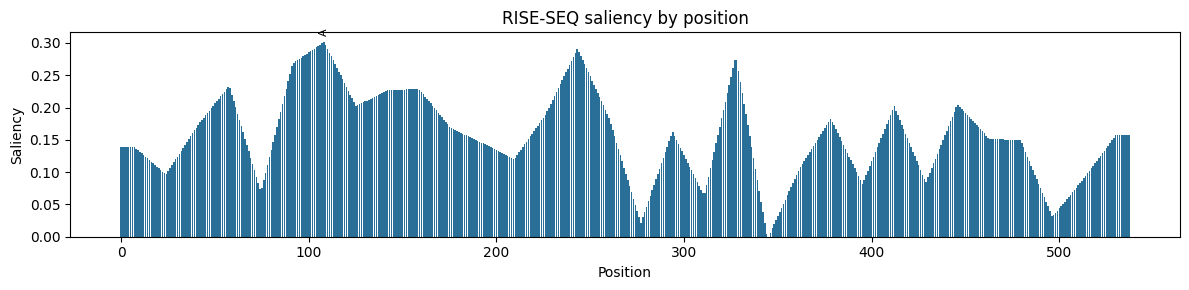

In [ ]:
import matplotlib.pyplot as plt

tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
values = saliency[1:-1]

# Topk positions
k = 1
top_idx = np.argsort(values)[-k:][::-1]

plt.figure(figsize=(12, 3))
plt.bar(range(len(values)), values, color="#2a6f97")
plt.title("RISE-SEQ saliency by position")
plt.xlabel("Position")
plt.ylabel("Saliency")

for i in top_idx:
    plt.text(i, values[i] + 0.01, tokens[i], ha="center", va="bottom", fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

## Heatmap + pseudo-logo

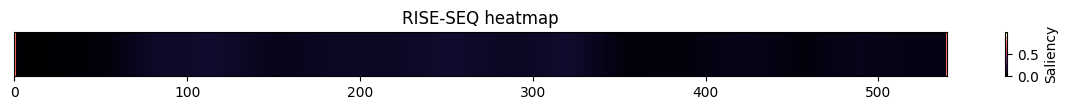

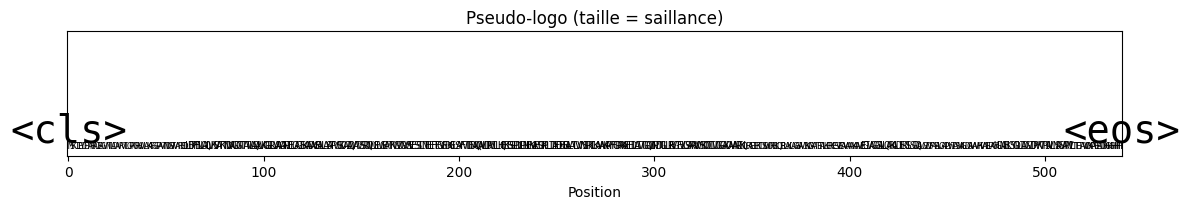

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
values = saliency

# Heatmap 1D des scores
plt.figure(figsize=(12, 1.2))
plt.imshow(values[None, :], aspect="auto", cmap="magma")
plt.yticks([])
plt.colorbar(label="Saliency")
plt.title("RISE-SEQ heatmap")
plt.tight_layout()
plt.show()

# Pseudo-logo: lettres redimensionnees selon la saillance
plt.figure(figsize=(12, 2.2))
ax = plt.gca()
ax.set_xlim(-0.5, len(values)-0.5)
ax.set_ylim(0, 1.05)
ax.set_yticks([])
ax.set_xlabel("Position")
ax.set_title("Pseudo-logo (taille = saillance)")

max_v = float(values.max()) if float(values.max()) > 0 else 1.0
for i, (tok, v) in enumerate(zip(tokens, values)):
    size = 6 + 22 * (v / max_v)
    ax.text(i, 0.05, tok, ha="center", va="bottom", fontsize=size, family="monospace")

plt.tight_layout()
plt.show()

## Insertion / Deletion (sequence)

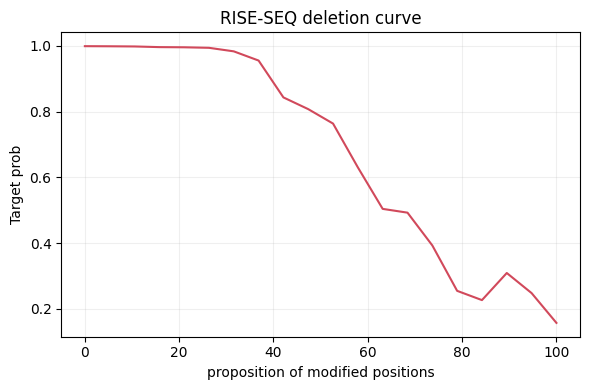

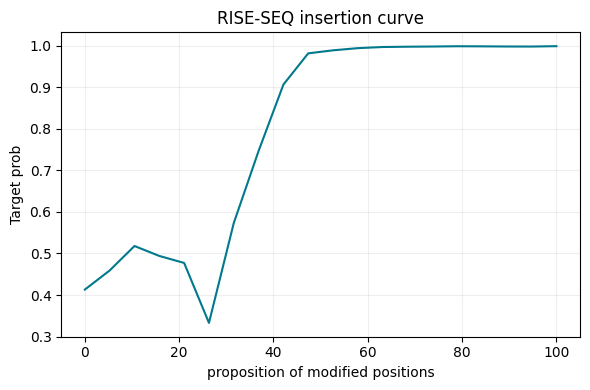

In [95]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def _special_positions(input_ids, tokenizer):
    specials = set(tokenizer.all_special_ids)
    mask = torch.zeros_like(input_ids, dtype=torch.bool)
    for sid in specials:
        mask = mask | (input_ids == sid)
    return mask

def seq_deletion_curve(model, input_ids, attention_mask, saliency, target_class, mask_token_id, steps=20, device="cpu", multi_label=True, tokenizer=None):
    sal = np.asarray(saliency).reshape(-1)
    ranking = np.argsort(sal)[::-1].copy()
    L = len(sal)
    specials = _special_positions(input_ids, tokenizer) if tokenizer else torch.zeros_like(input_ids, dtype=torch.bool)
    probs = []
    model.eval()
    with torch.no_grad():
        for k in range(steps):
            n = (k * L) // steps
            ids = input_ids.clone()
            idx = ranking[:n]
            ids[0, idx] = mask_token_id
            ids = torch.where(specials, input_ids, ids)
            logits = model(input_ids=ids.to(device), attention_mask=attention_mask.to(device)).logits
            if multi_label:
                prob = torch.sigmoid(logits)[0, target_class].item()
            else:
                prob = torch.softmax(logits, dim=1)[0, target_class].item()
            probs.append(prob)
    return np.array(probs, dtype=np.float32)

def seq_insertion_curve(model, input_ids, attention_mask, saliency, target_class, mask_token_id, steps=20, device="cpu", multi_label=True, tokenizer=None):
    sal = np.asarray(saliency).reshape(-1)
    ranking = np.argsort(sal)[::-1].copy()
    L = len(sal)
    specials = _special_positions(input_ids, tokenizer) if tokenizer else torch.zeros_like(input_ids, dtype=torch.bool)
    base = input_ids.clone()
    base[:] = mask_token_id
    base = torch.where(specials, input_ids, base)
    probs = []
    model.eval()
    with torch.no_grad():
        for k in range(steps):
            n = (k * L) // steps
            idx = ranking[:n]
            ids = base.clone()
            ids[0, idx] = input_ids[0, idx]
            ids = torch.where(specials, input_ids, ids)
            logits = model(input_ids=ids.to(device), attention_mask=attention_mask.to(device)).logits
            if multi_label:
                prob = torch.sigmoid(logits)[0, target_class].item()
            else:
                prob = torch.softmax(logits, dim=1)[0, target_class].item()
            probs.append(prob)
    return np.array(probs, dtype=np.float32)

steps = 20
del_curve = seq_deletion_curve(model, input_ids, attention_mask, saliency, target_class, tokenizer.mask_token_id, steps=steps, device=device, multi_label=True, tokenizer=tokenizer)
ins_curve = seq_insertion_curve(model, input_ids, attention_mask, saliency, target_class, tokenizer.mask_token_id, steps=steps, device=device, multi_label=True, tokenizer=tokenizer)

x = np.linspace(0, 100, steps)
plt.figure(figsize=(6, 4))
plt.plot(x, del_curve, color="#d1495b")
plt.xlabel("proposition of modified positions")
plt.ylabel("Target prob")
plt.title("RISE-SEQ deletion curve")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(x, ins_curve, color="#00798c")
plt.xlabel("proposition of modified positions")
plt.ylabel("Target prob")
plt.title("RISE-SEQ insertion curve")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

RISE-SEQ: 100%|██████████| 32/32 [05:17<00:00,  9.93s/it]


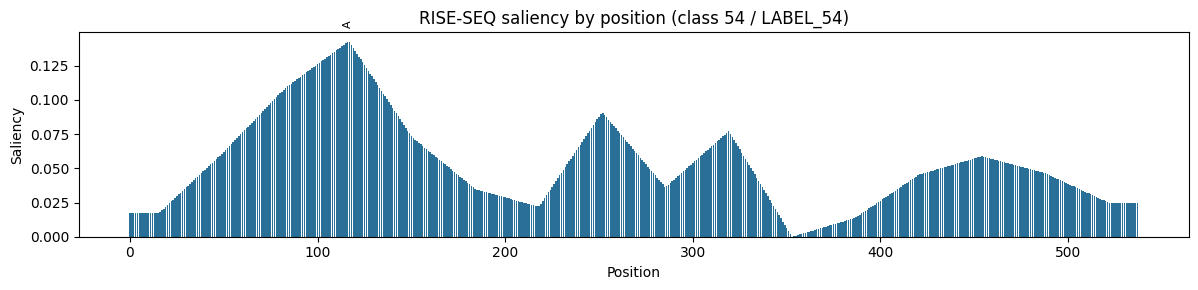

RISE-SEQ: 100%|██████████| 32/32 [05:37<00:00, 10.54s/it]


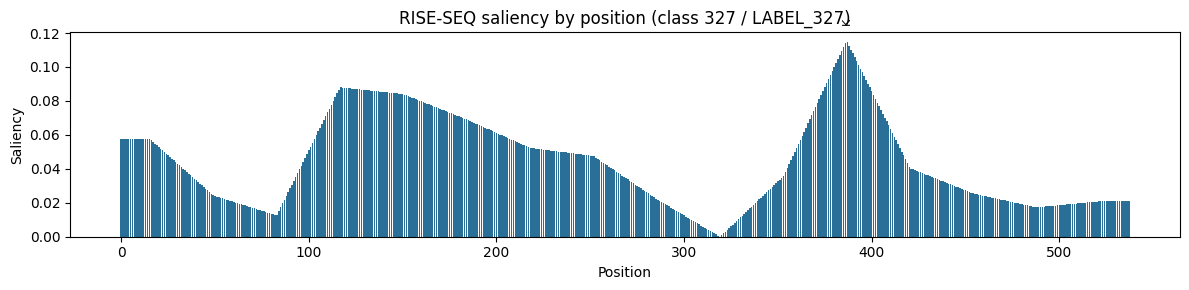

RISE-SEQ: 100%|██████████| 32/32 [05:36<00:00, 10.53s/it]


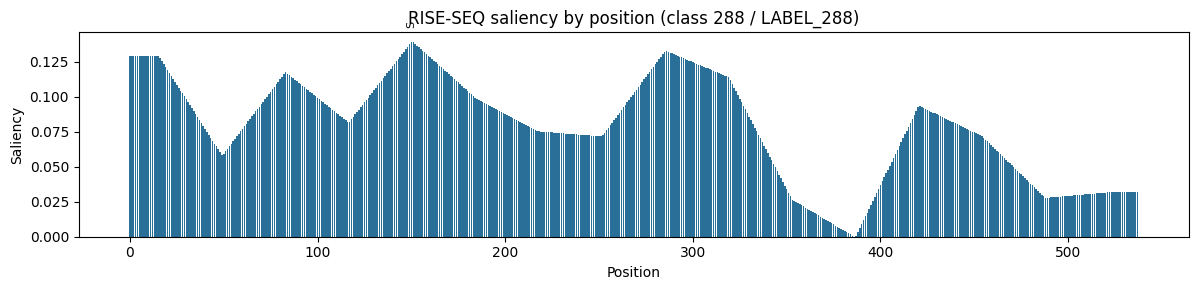

RISE-SEQ: 100%|██████████| 32/32 [05:36<00:00, 10.51s/it]


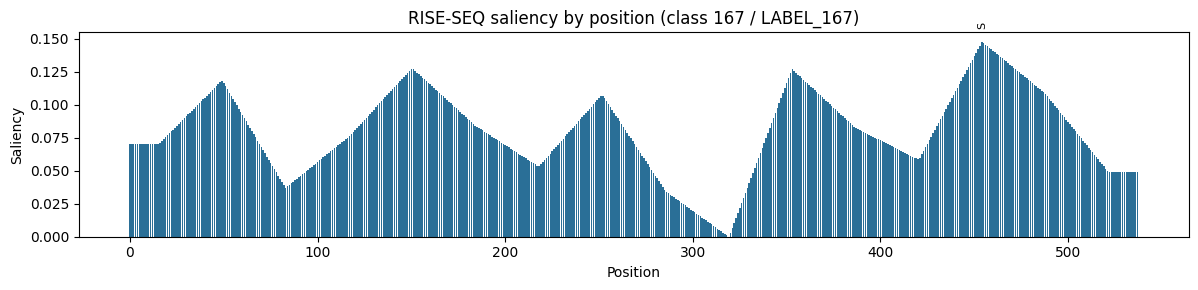

RISE-SEQ: 100%|██████████| 32/32 [36:54<00:00, 69.19s/it]  


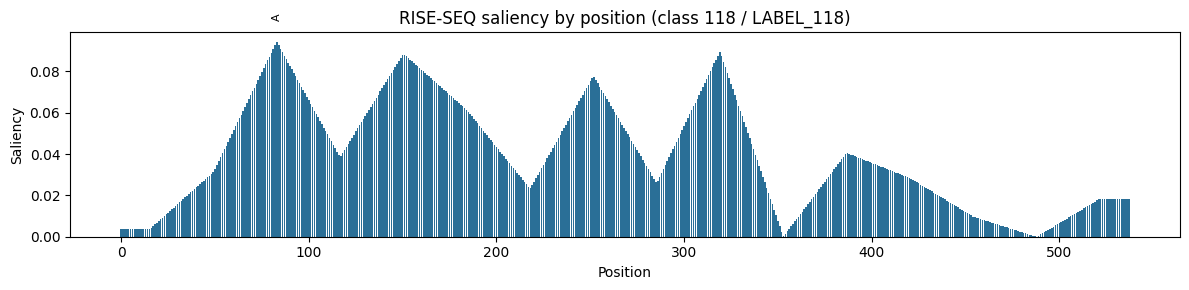

RISE-SEQ: 100%|██████████| 32/32 [04:47<00:00,  8.97s/it]


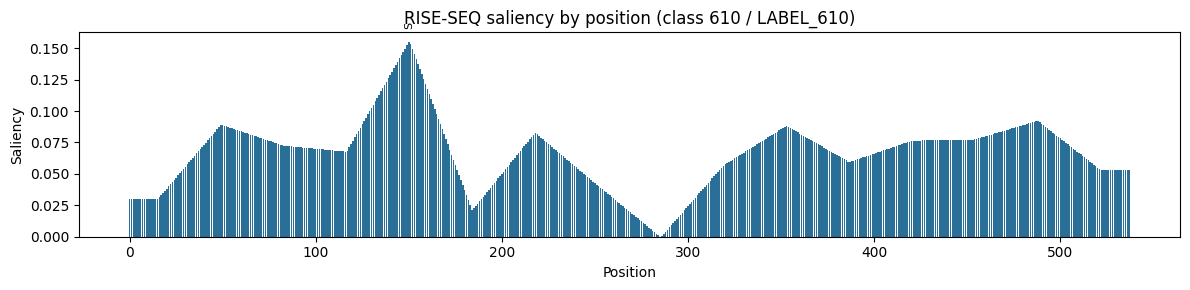

RISE-SEQ: 100%|██████████| 32/32 [04:51<00:00,  9.10s/it]


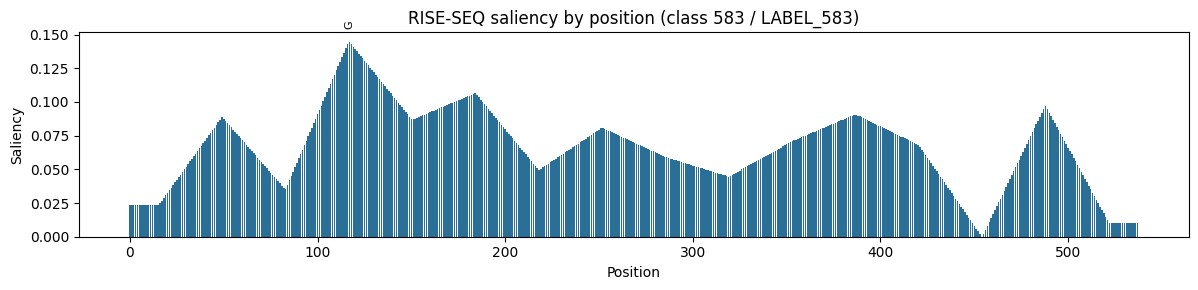

RISE-SEQ: 100%|██████████| 32/32 [04:55<00:00,  9.22s/it]


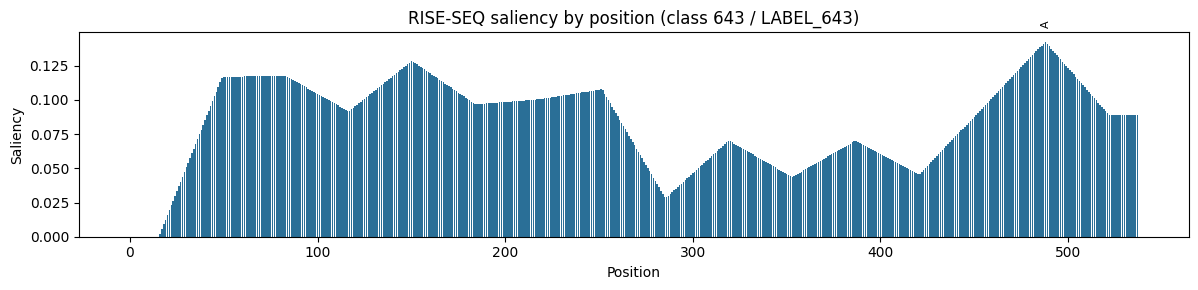

RISE-SEQ: 100%|██████████| 32/32 [04:46<00:00,  8.94s/it]


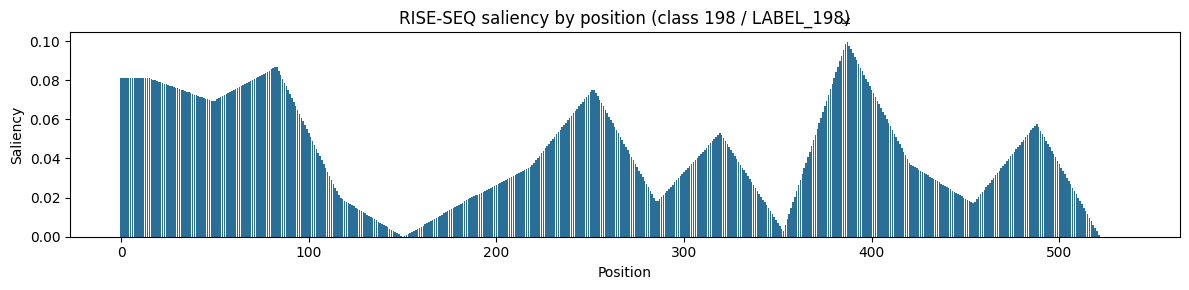

RISE-SEQ: 100%|██████████| 32/32 [05:35<00:00, 10.48s/it]


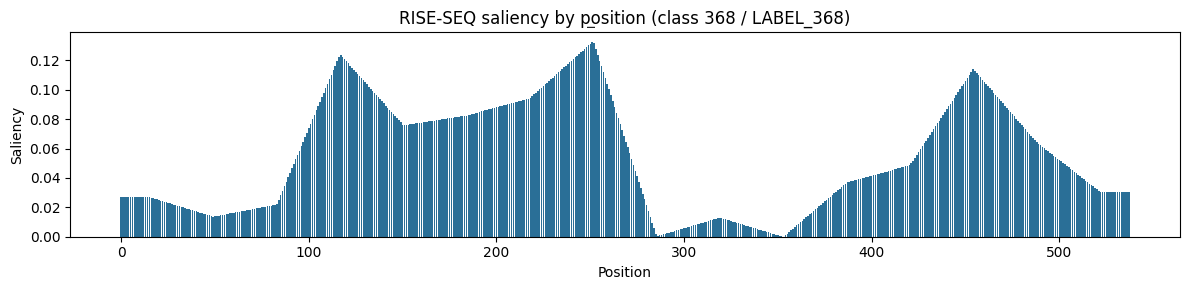

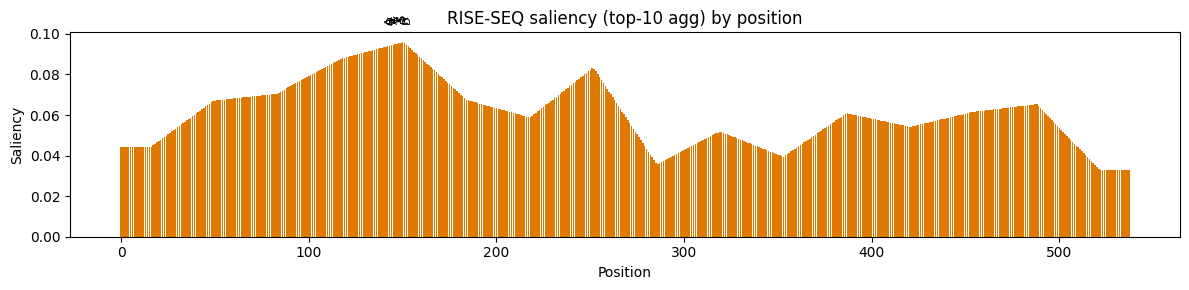

In [ ]:
# RISE-SEQ top-10 Pfam + aggregation
import numpy as np
import matplotlib.pyplot as plt
 
# Top-10 classes (multi-label assumed; switch to softmax if needed)
with torch.no_grad():
    logits = model(input_ids=input_ids.to(device), attention_mask=attention_mask.to(device)).logits
probs = torch.sigmoid(logits)[0]
topk = torch.topk(probs, 10)
 
tokens_all = tokenizer.convert_ids_to_tokens(input_ids[0])
special_ids = set(tokenizer.all_special_ids)
keep_idx = [i for i, tid in enumerate(input_ids[0].tolist()) if tid not in special_ids]
tokens = [tokens_all[i] for i in keep_idx]
 
agg = None
for score, cls in zip(topk.values, topk.indices):
    sal = compute_rise_saliency_seq(
        model=model,
        input_ids=input_ids,
        attention_mask=attention_mask,
        pred_class=int(cls),
        mask_token_id=tokenizer.mask_token_id,
        num_masks=1000,
        p1=0.5,
        s=16,
        device=device,
        batch_size=32,
        special_token_ids=tokenizer.all_special_ids,
        multi_label=True,
    )
    values = np.asarray(sal)[keep_idx]

    # plot per-class
    k = 1
    top_idx = np.argsort(values)[-k:][::-1]
    plt.figure(figsize=(12, 3))
    plt.bar(range(len(values)), values, color="#2a6f97")
    plt.title(f"RISE-SEQ saliency by position (class {int(cls)} / {label_name(int(cls))})")
    plt.xlabel("Position")
    plt.ylabel("Saliency")
    for i in top_idx:
        plt.text(i, values[i] + 0.01, tokens[i], ha="center", va="bottom", fontsize=8, rotation=90)
    plt.tight_layout()
    plt.show()

    # aggregate (weighted by class prob)
    w = float(score)
    agg = values * w if agg is None else agg + values * w
 
# Aggregate plot across top-10 classes
agg = agg / topk.values.sum().item()
k = 10
top_idx = np.argsort(agg)[-k:][::-1]
plt.figure(figsize=(12, 3))
plt.bar(range(len(agg)), agg, color="#e07902")
plt.title("RISE-SEQ saliency (top-10 agg) by position")
plt.xlabel("Position")
plt.ylabel("Saliency")
for i in top_idx:
    plt.text(i, agg[i] + 0.01, tokens[i], ha="center", va="bottom", fontsize=8, rotation=90)
plt.tight_layout()
plt.show()
